![Logo Javeriana](https://images.seeklogo.com/logo-png/11/1/pontificia-universidad-javeriana-logo-png_seeklogo-110703.png)

## Nombres: 
- Gabriel Jaramillo Cuberos (Id: 20529022)
- Samuel Beltrán Martínez (Id: 20524509)
- David Vargas (Id: 20485686)
- Juan Felipe Gómez López (Id: 20553416)
- Sara Pulgarín (Id: 20491129)
- Juan Camilo Delgado (Id: 20506996)

### Primera entrega del proyecto

*Materia:* Procesamiento de Datos (1255)

*Tema:* Consultoría Nueva York.

*Descripción:* En este cuaderno se realiza el bono de web scraping

*Nombre del fichero:* 01_Bono_NYHealth.ipynb

## 1. Identificacion del dataset en el portal

Este notebook obtiene, limpia y valida datos de poblacion por county del estado de Nueva York, publicados en el portal oficial **Health Data NY** (https://health.data.ny.gov/).

El portal Health Data NY organiza sus datos en distintas colecciones de "Public Use Files" (PUFs), entre ellas la coleccion de **County PUFs**, accesible desde la pagina principal del portal en la seccion "County PUFs" (enlace `https://health.data.ny.gov/browse?sortBy=alpha&pageSize=20&q=county&limitTo=datasets`).

Explorando el catalogo del portal se identifico el dataset **"New York State Population Data: Beginning 2003"**, publicado por el New York State Department of Health dentro de la coleccion de Vital Statistics PUFs. Este dataset cumple con los requisitos del proyecto porque:

- Contiene poblacion por county de todo el estado de Nueva York, incluyendo los cinco counties que conforman la ciudad de Nueva York.
- Incluye la variable Year, lo que permite trabajar con series anuales.

La pagina del dataset dentro del portal es:

`https://health.data.ny.gov/Health/New-York-State-Population-Data-Beginning-2003/e9uj-s3sf`

## 2. Preparación del entorno

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import json
import os

## 3. Descarga de los datos

Se descarga el archivo CSV publico del dataset de poblacion y se guarda una copia local

In [2]:
URL_DATASET = "https://health.data.ny.gov/api/views/e9uj-s3sf/rows.csv?accessType=DOWNLOAD"

os.makedirs("datos", exist_ok=True)
ruta_local = os.path.join("datos", "poblacion_ny_por_county.csv")

respuesta = requests.get(URL_DATASET, timeout=60)
respuesta.raise_for_status()

with open(ruta_local, "wb") as archivo:
    archivo.write(respuesta.content)

print("Descarga completada")
print("Codigo de estado HTTP:", respuesta.status_code)
print("Tamanio del archivo en bytes:", len(respuesta.content))

Descarga completada
Codigo de estado HTTP: 200
Tamanio del archivo en bytes: 12836478


## 4. Carga y exploracion inicial de los datos

Se carga el archivo descargado con pandas y se hace una primera inspeccion de su estructura, sus columnas y los valores unicos de la columna de counties.

In [6]:
df_bruto = pd.read_csv(ruta_local)

print("Dimensiones del dataframe:", df_bruto.shape)
print()
print("Columnas disponibles:")
print(list(df_bruto.columns))
print()
print("Valores unicos en la columna County Name:")
print(sorted(df_bruto["County Name"].unique()))



Dimensiones del dataframe: (236340, 10)

Columnas disponibles:
['Year', 'Age Group Code', 'Age Group Description', 'Gender Code', 'Gender Description', 'Race Ethnicity Code', 'Race/Ethnicity Description', 'County Code', 'County Name', 'Population']

Valores unicos en la columna County Name:
['Albany', 'Allegany', 'Bronx', 'Broome', 'Cattaraugus', 'Cayuga', 'Chautauqua', 'Chemung', 'Chenango', 'Clinton', 'Columbia', 'Cortland', 'Delaware', 'Dutchess', 'Erie', 'Essex', 'Franklin', 'Fulton', 'Genesee', 'Greene', 'Hamilton', 'Herkimer', 'Jefferson', 'Kings', 'Lewis', 'Livingston', 'Madison', 'Monroe', 'Montgomery', 'Nassau', 'New York', 'New York City', 'New York State', 'Niagara', 'Oneida', 'Onondaga', 'Ontario', 'Orange', 'Orleans', 'Oswego', 'Otsego', 'Putnam', 'Queens', 'Rensselaer', 'Rest of State', 'Richmond', 'Rockland', 'Saratoga', 'Schenectady', 'Schoharie', 'Schuyler', 'Seneca', 'St Lawrence', 'Steuben', 'Suffolk', 'Sullivan', 'Tioga', 'Tompkins', 'Ulster', 'Warren', 'Washington'

## 5. Filtrado de los cinco counties de la ciudad de Nueva York

De acuerdo con la correspondencia oficial entre boroughs y counties, la ciudad de Nueva York esta compuesta por los siguientes cinco counties:

- Bronx corresponde a Bronx County
- Brooklyn corresponde a Kings County
- Manhattan corresponde a New York County
- Queens corresponde a Queens County
- Staten Island corresponde a Richmond County

In [7]:
counties_nyc = ["Bronx", "Kings", "New York", "Queens", "Richmond"]

df_nyc = df_bruto[df_bruto["County Name"].isin(counties_nyc)].copy()

print("Registros totales antes del filtro:", len(df_bruto))
print("Registros correspondientes a los counties de NYC:", len(df_nyc))
print()
print("Counties presentes despues del filtro:")
print(sorted(df_nyc["County Name"].unique()))

Registros totales antes del filtro: 236340
Registros correspondientes a los counties de NYC: 18180

Counties presentes despues del filtro:
['Bronx', 'Kings', 'New York', 'Queens', 'Richmond']


## 6. Seleccion de columnas relevantes

El dataset original incluye desagregaciones por grupo de edad (Age Group Description), sexo (Gender Description) y raza o etnia (Race/Ethnicity Description). Estas desagregaciones son utiles para estudios demograficos mas detallados, pero para este proyecto lo que se necesita es la poblacion total por county y por anio, que es la base minima para construir indicadores relativos como tasas por cada 100000 habitantes.

Por esta razon se conservan unicamente los registros donde Age Group Description, Gender Description y Race/Ethnicity Description tienen el valor "Total", que corresponde a la poblacion total sin desagregar. Las columnas finales que se conservan son County Name, Year y Population.


In [12]:
anios_disponibles = sorted(df_nyc["Year"].unique())
print("Anios disponibles en el dataset para los counties de NYC:")
print(anios_disponibles)

anio_objetivo = 2018

filtro_totales = (
    (df_anio["Age Group Description"] == "Total") &
    (df_anio["Gender Description"] == "Total") &
    (df_anio["Race/Ethnicity Description"] == "Total")
)
print()
df_totales = df_anio[filtro_totales].copy()

df_totales = df_totales[["County Name", "Year", "Population"]].copy()

print("Registros de poblacion total por county para el anio", anio_objetivo)
print(df_totales)

Anios disponibles en el dataset para los counties de NYC:
[np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]

Registros de poblacion total por county para el anio 2018
       County Name  Year  Population
199467       Bronx  2018     1432132
199488       Kings  2018     2582830
199495    New York  2018     1628701
199505      Queens  2018     2278906
199507    Richmond  2018      476179


## 7. Limpieza de nombres de county y creacion de la columna borough

Se limpian los nombres de county eliminando espacios sobrantes y se crea una nueva columna llamada borough usando la correspondencia oficial entre boroughs y counties indicada al inicio del proyecto


In [13]:
df_totales["County Name"] = df_totales["County Name"].str.strip()

correspondencia_borough = {
    "Bronx": "Bronx",
    "Kings": "Brooklyn",
    "New York": "Manhattan",
    "Queens": "Queens",
    "Richmond": "Staten Island"
}

df_totales["borough"] = df_totales["County Name"].map(correspondencia_borough)

df_totales = df_totales.rename(columns={
    "County Name": "county",
    "Year": "year",
    "Population": "population"
})

df_totales = df_totales[["borough", "county", "year", "population"]]

print(df_totales)


              borough    county  year  population
199467          Bronx     Bronx  2018     1432132
199488       Brooklyn     Kings  2018     2582830
199495      Manhattan  New York  2018     1628701
199505         Queens    Queens  2018     2278906
199507  Staten Island  Richmond  2018      476179


## 8. Verificacion de valores faltantes, duplicados y tipos de datos, asi mismo tabla final

In [15]:
print("Valores faltantes por columna:")
print(df_totales.isnull().sum())
print()

print("Numero de registros duplicados:")
print(df_totales.duplicated().sum())
print()

print("Tipos de datos por columna:")
print(df_totales.dtypes)
print()

print("Numero de boroughs unicos encontrados:", df_totales["borough"].nunique())
print("Se esperan exactamente 5 boroughs, uno por cada county de NYC")
print()
tabla_final = df_totales.sort_values(by="population", ascending=False).reset_index(drop=True)
tabla_final

Valores faltantes por columna:
borough       0
county        0
year          0
population    0
dtype: int64

Numero de registros duplicados:
0

Tipos de datos por columna:
borough         str
county          str
year          int64
population    int64
dtype: object

Numero de boroughs unicos encontrados: 5
Se esperan exactamente 5 boroughs, uno por cada county de NYC



,borough,county,year,population
0,Brooklyn,Kings,2018,2582830
1,Queens,Queens,2018,2278906
2,Manhattan,New York,2018,1628701
3,Bronx,Bronx,2018,1432132
4,Staten Island,Richmond,2018,476179


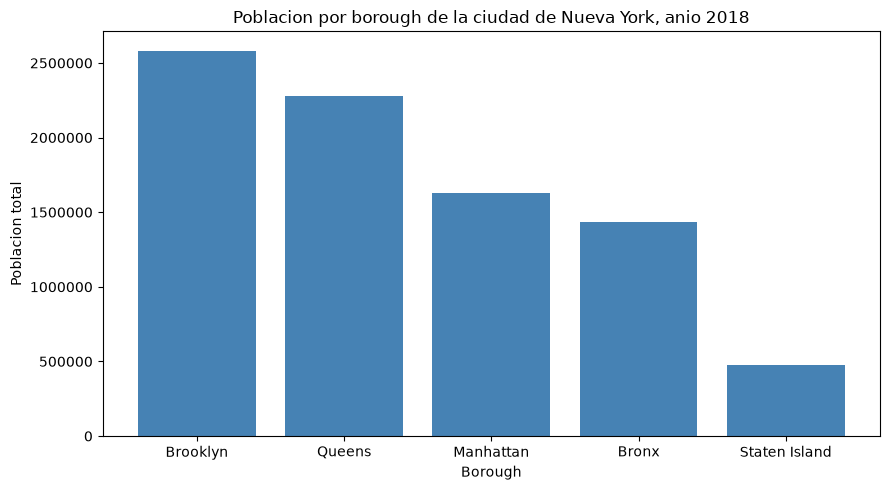

In [16]:
orden_grafica = tabla_final.sort_values(by="population", ascending=False)

plt.figure(figsize=(9, 5))
plt.bar(orden_grafica["borough"], orden_grafica["population"], color="steelblue")
plt.title("Poblacion por borough de la ciudad de Nueva York, anio " + str(anio_objetivo))
plt.xlabel("Borough")
plt.ylabel("Poblacion total")
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()